# Advanced Certification Program in Computational Data Science
## A program by IISc and TalentSprint
### Mini-Project: Exploratory Data Analysis - Timeseries

## Problem Statement

Perform Exploratory Data Analysis (EDA) of Retail Sales time series data using visualizations and statistical methods.

## Learning Objectives

At the end of the mini-project, you will be able to :

* perform Exploratory data analysis (EDA) of the time series
* perform Time series behaviour analysis in qualitative and quantitative terms
* summarize the findings based on the EDA

## Dataset

The dataset is a French retail company quarterly sales data that has been made available from  Prof. Rob Hyndman's ["Forecasting Methods & Applications"](https://robjhyndman.com/forecasting/) book. There are 24 entries, from 2012-03-31 to 2017-12-31 (Quarterly sales values).

## Introduction

Exploratory data analysis of time series data starts with data visualization.

- Are there consistent patterns?
- Is there a significant trend?
- Is seasonality important?
- Is there evidence of the presence of business cycles?
- Are there any outliers in the data that need to be explained by those with expert knowledge?
- How strong are the relationships among the variables available for analysis?

Various tools have been developed to help with these analyses.

## Grading = 10 Points

In [1]:
# @title Download Dataset
# !wget -qq https://cdn.iisc.talentsprint.com/CDS/Datasets/ts_frenchretail.csv

from utility import download_and_unzip

download_and_unzip(
    filename="ts_frenchretail.csv",
    url="https://cdn.iisc.talentsprint.com/CDS/Datasets/ts_frenchretail.csv",
)

print("Data downloaded successfully")


Data downloaded successfully


### Importing libraries


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-white")
%matplotlib inline
import scipy
from pandas.plotting import lag_plot
from statsmodels.graphics.tsaplots import month_plot, seasonal_plot, quarter_plot
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy import signal
import warnings

warnings.filterwarnings("ignore")
np.random.seed(42)


### Import the Data

In [3]:
# Read dataset with 'Date' as index
# YOUR CODE HERE
sales_data = pd.read_csv("ts_frenchretail.csv", index_col="Date", parse_dates=True)

print("Original Sales Data Head:")
print(sales_data.head())
print("\nOriginal Sales Data Info:")
sales_data.info()


Original Sales Data Head:
             Sales
Date              
2012-03-31  362000
2012-06-30  385000
2012-09-30  432000
2012-12-31  341000
2013-03-31  382000

Original Sales Data Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 24 entries, 2012-03-31 to 2017-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Sales   24 non-null     int64
dtypes: int64(1)
memory usage: 384.0 bytes


In [4]:
sales_data


,Sales
Date,
2012-03-31,362000
2012-06-30,385000
2012-09-30,432000
2012-12-31,341000
2013-03-31,382000
2013-06-30,409000
2013-09-30,498000
2013-12-31,387000
2014-03-31,473000


## Exploratory Data Analysis

### **Preprocessing** (1 point)

#### Divide the sales by 1000

Sales numbers are in thousands, so divide by 1000 to make it easier to work with numbers

In [5]:
# YOUR CODE HERE
sales_data["Sales"] = sales_data["Sales"] / 1000
print("\nSales data after dividing by 1000:")
print(sales_data.head())



Sales data after dividing by 1000:
            Sales
Date             
2012-03-31  362.0
2012-06-30  385.0
2012-09-30  432.0
2012-12-31  341.0
2013-03-31  382.0


#### Check for missing values     

In [6]:
# YOUR CODE HERE
print("\nMissing values in the dataset:")
print(sales_data.isnull().sum())
if sales_data.isnull().sum().sum() == 0:
    print("No missing values found.")
else:
    print(
        "Missing values detected. Consider imputation if necessary for further analysis."
    )



Missing values in the dataset:
Sales    0
dtype: int64
No missing values found.


### **Visualization**

#### Visualize the time series (2012 to 2017) (1 point)

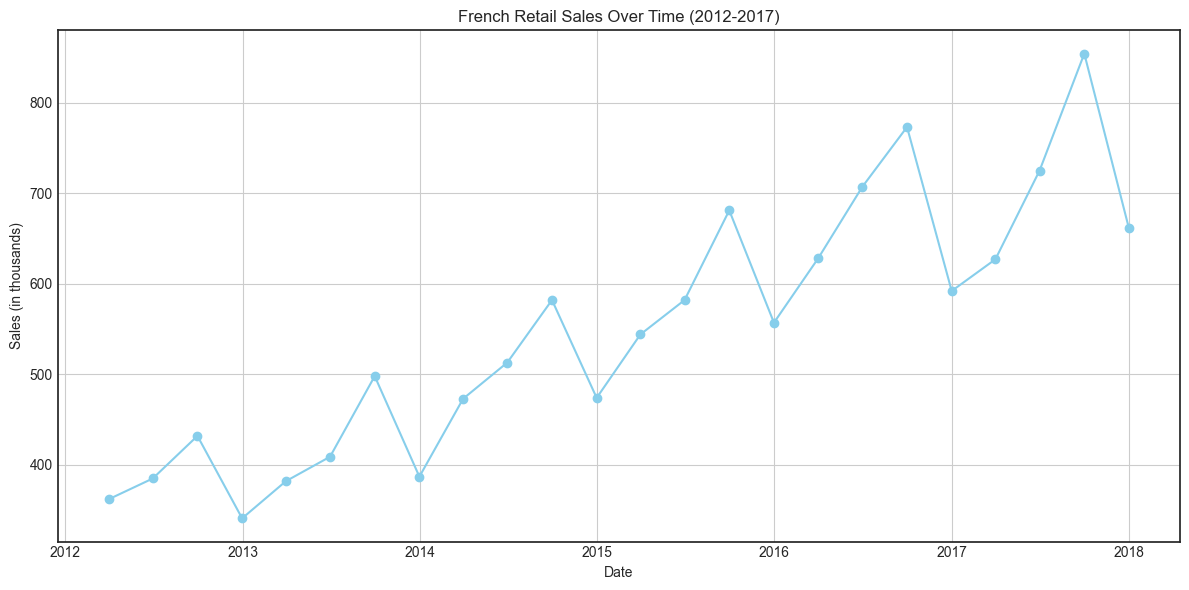

In [7]:
# YOUR CODE HERE
plt.figure(figsize=(12, 6))
plt.plot(
    sales_data.index, sales_data["Sales"], marker="o", linestyle="-", color="skyblue"
)
plt.title("French Retail Sales Over Time (2012-2017)")
plt.xlabel("Date")
plt.ylabel("Sales (in thousands)")
plt.grid(True)
plt.tight_layout()
plt.show()


#### Visualize the data year-wise and quarter-wise (2 points)

- Box plot to see distribution of sales in each year
- Create year-wise subplots to visualize the quarterly Sales per year
- Compute Percentage growth each year

Make a report of your observations.

In [8]:
sales_data["Year"] = sales_data.index.year
sales_data["Quarter"] = sales_data.index.quarter


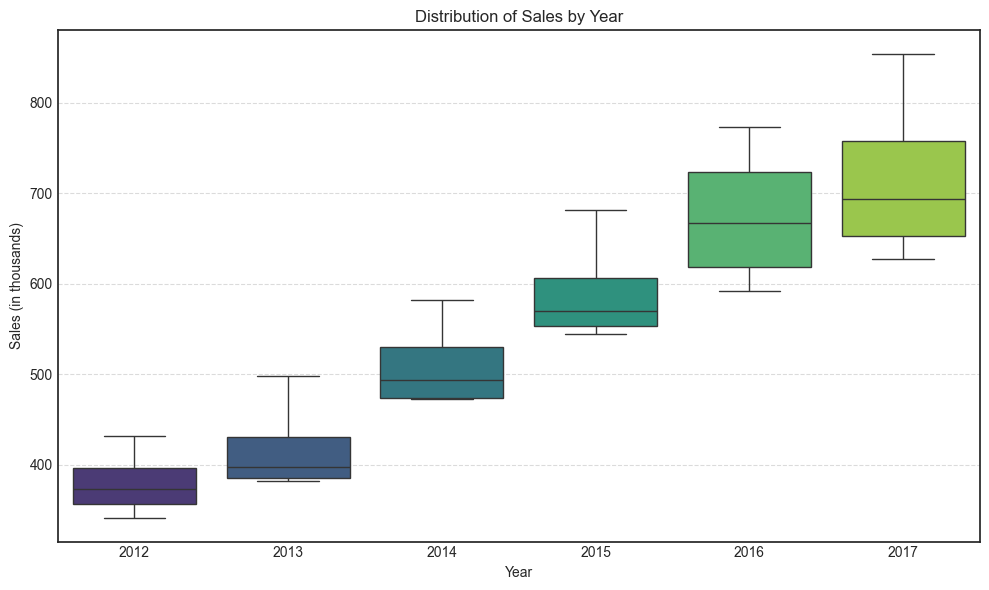

In [9]:
# Box plot to see distribution of sales in each year
# YOUR CODE HERE
plt.figure(figsize=(10, 6))
sns.boxplot(x="Year", y="Sales", data=sales_data, palette="viridis")
plt.title("Distribution of Sales by Year")
plt.xlabel("Year")
plt.ylabel("Sales (in thousands)")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


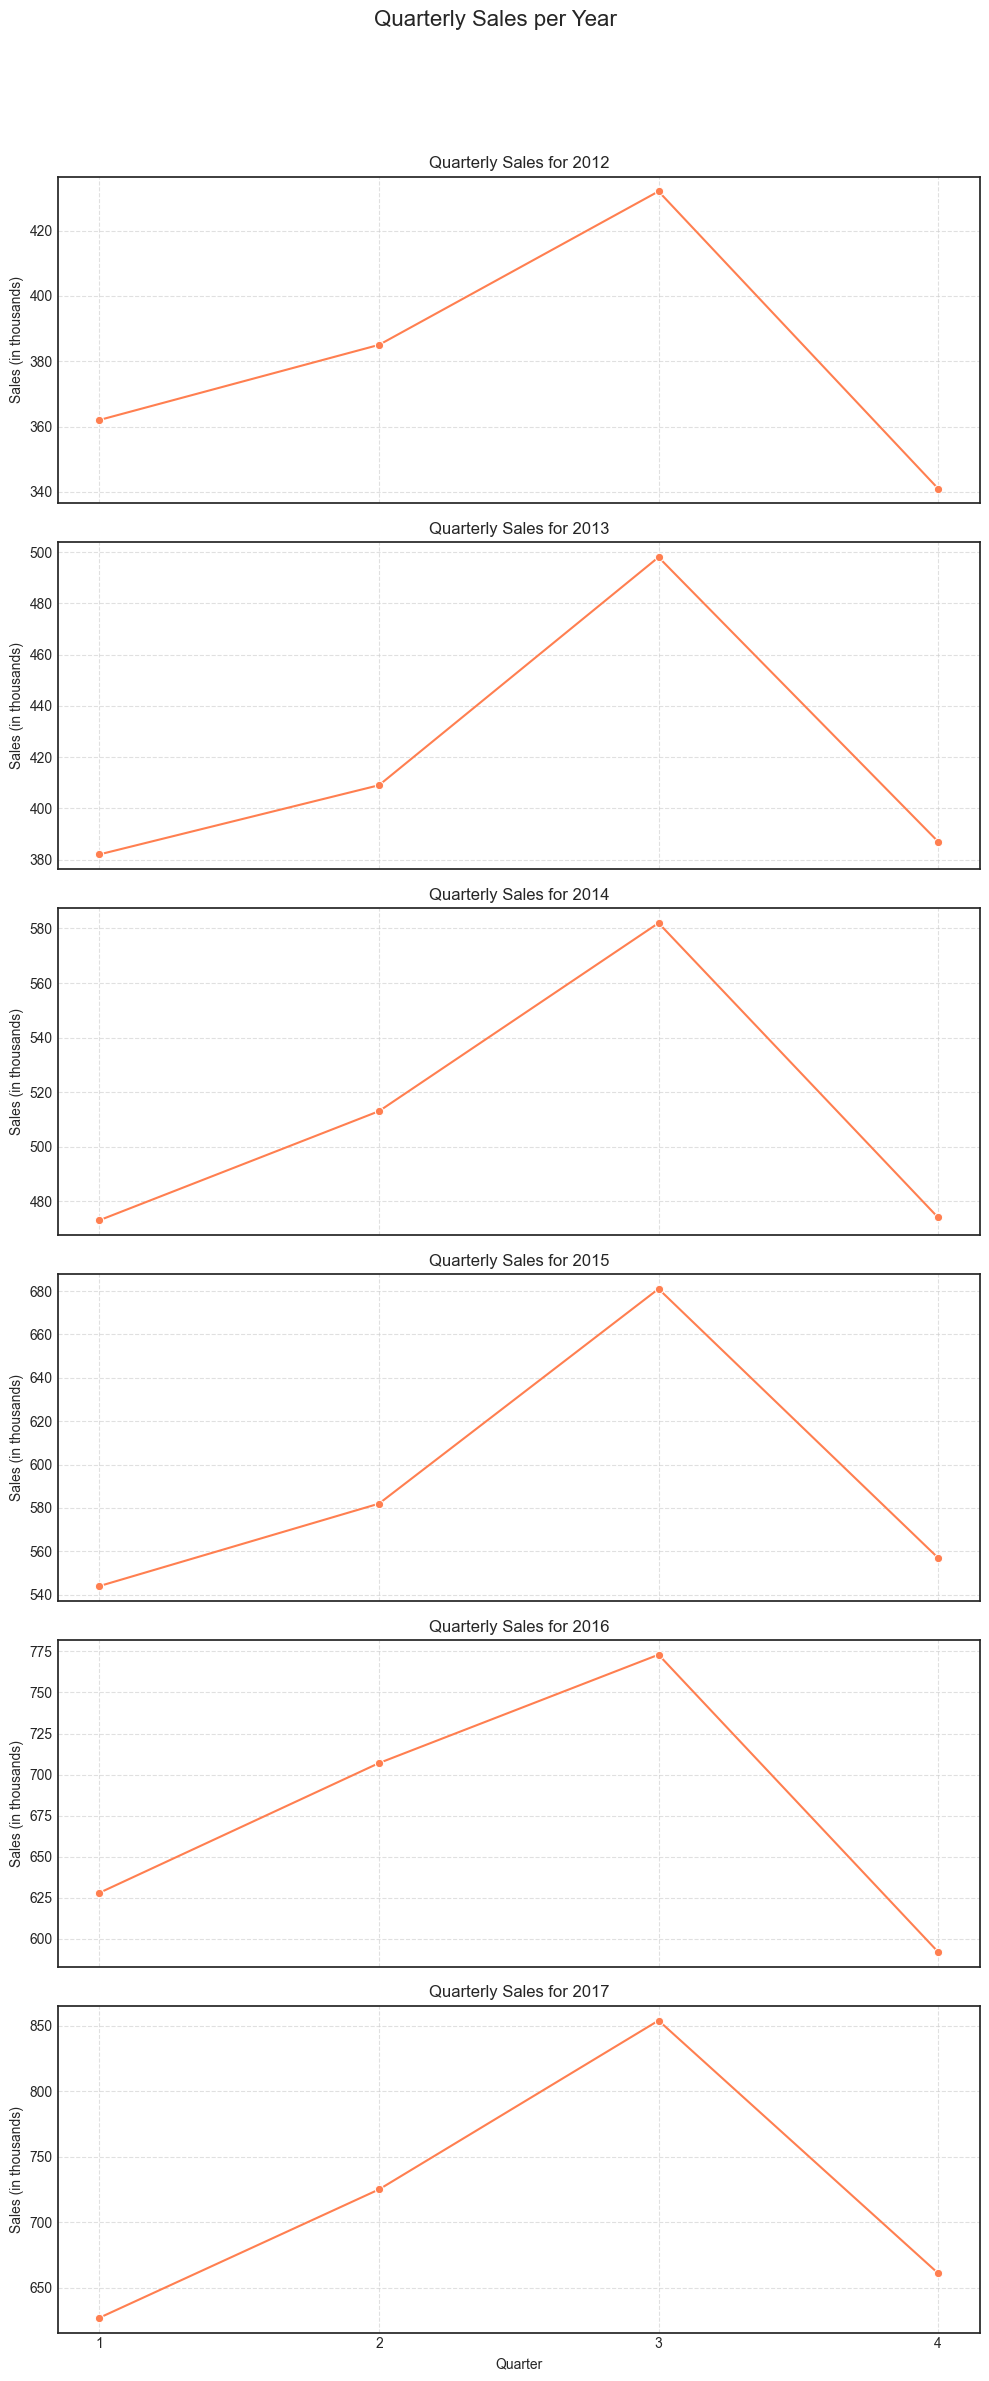

In [10]:
# Create year-wise subplots to visualize the quarterly Sales per year
# YOUR CODE HERE
years = sales_data["Year"].unique()
fig, axes = plt.subplots(
    nrows=len(years), ncols=1, figsize=(10, 4 * len(years)), sharex=True
)
axes = axes.flatten()  # Flatten in case there's only one year

for i, year in enumerate(years):
    yearly_data = sales_data[sales_data["Year"] == year]
    sns.lineplot(
        x="Quarter", y="Sales", data=yearly_data, marker="o", ax=axes[i], color="coral"
    )
    axes[i].set_title(f"Quarterly Sales for {year}")
    axes[i].set_xlabel("Quarter")
    axes[i].set_ylabel("Sales (in thousands)")
    axes[i].set_xticks([1, 2, 3, 4])
    axes[i].grid(True, linestyle="--", alpha=0.6)

plt.suptitle("Quarterly Sales per Year", y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])  # Adjust layout to prevent title overlap
plt.show()


In [11]:
# Percentage growth each year
# YOUR CODE HERE
yearly_sales = sales_data.groupby("Year")["Sales"].sum()
percentage_growth = yearly_sales.pct_change() * 100
print("\nPercentage Growth Each Year:")
print(percentage_growth)

print("\n--- Report on Year-wise and Quarter-wise Observations ---")
print(
    "1. **Box Plot Observation:** The box plot shows an increasing trend in median sales over the years, indicating overall growth. The spread (interquartile range) also appears to be relatively consistent or slightly increasing, suggesting stable variability within each year."
)
print(
    "2. **Quarterly Sales Subplots Observation:** For each year, there's a clear seasonal pattern, with sales generally peaking in Q4 (Quarter 4) and being lowest in Q1 (Quarter 1). This indicates strong seasonality in retail sales, likely driven by holiday seasons."
)
print(
    "3. **Percentage Growth Observation:** The percentage growth data quantifies the year-over-year increase in total sales. Positive growth percentages indicate consistent expansion of the business."
)



Percentage Growth Each Year:
Year
2012          NaN
2013    10.263158
2014    21.837709
2015    15.768854
2016    14.213198
2017     6.185185
Name: Sales, dtype: float64

--- Report on Year-wise and Quarter-wise Observations ---
1. **Box Plot Observation:** The box plot shows an increasing trend in median sales over the years, indicating overall growth. The spread (interquartile range) also appears to be relatively consistent or slightly increasing, suggesting stable variability within each year.
2. **Quarterly Sales Subplots Observation:** For each year, there's a clear seasonal pattern, with sales generally peaking in Q4 (Quarter 4) and being lowest in Q1 (Quarter 1). This indicates strong seasonality in retail sales, likely driven by holiday seasons.
3. **Percentage Growth Observation:** The percentage growth data quantifies the year-over-year increase in total sales. Positive growth percentages indicate consistent expansion of the business.


#### Visualize the distribution of the Sales (0.5 point)

While normally distributed data is not a requirement for forecasting and doesn't necessarily improve point forecast accuracy, it can help stablize the variance and narrow the prediction interval.

Report your observations.

Hint: `sns.distplot()`

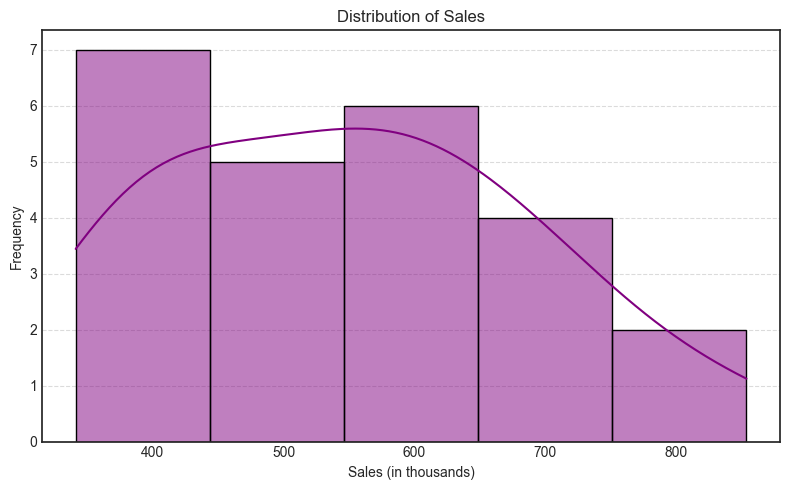


--- Report on Sales Distribution Observations ---
The distribution of sales appears to be somewhat skewed to the right, with a longer tail towards higher sales values. This suggests that while most sales figures fall within a certain range, there are fewer instances of very high sales. The presence of a clear peak indicates a common range for quarterly sales.


In [12]:
# YOUR CODE HERE

plt.figure(figsize=(8, 5))
sns.histplot(
    sales_data["Sales"], kde=True, color="purple", bins=5
)  # Reduced bins for quarterly data
plt.title("Distribution of Sales")
plt.xlabel("Sales (in thousands)")
plt.ylabel("Frequency")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

print("\n--- Report on Sales Distribution Observations ---")
print(
    "The distribution of sales appears to be somewhat skewed to the right, with a longer tail towards higher sales values. This suggests that while most sales figures fall within a certain range, there are fewer instances of very high sales. The presence of a clear peak indicates a common range for quarterly sales."
)


#### Visualize Quarterly trends (1 point)

Create quarterly subplots to visualize the data in each quarter across all years

Hint: statsmodels' `quarter_plot()` method

<Figure size 1000x700 with 0 Axes>

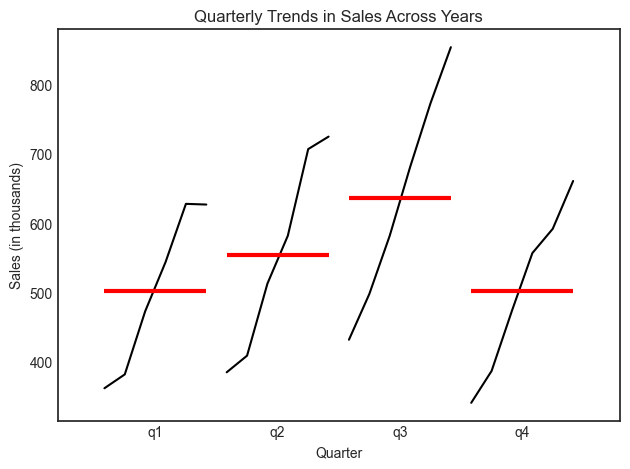

In [13]:
# YOUR CODE HERE
plt.figure(figsize=(10, 7))
quarter_plot(sales_data["Sales"])
plt.title("Quarterly Trends in Sales Across Years")
plt.xlabel("Quarter")
plt.ylabel("Sales (in thousands)")
plt.tight_layout()
plt.show()


#### Visualize the distribution of Sales in each year within a single plot (1 point)

- Do the distribution peaks shift to the right from 2012 to 2017? What does this indicate?
- Is there a change in the width of the distributions from 2012 to 2017? What does it signify?

Hint: `sns.distplot(hist=False)`

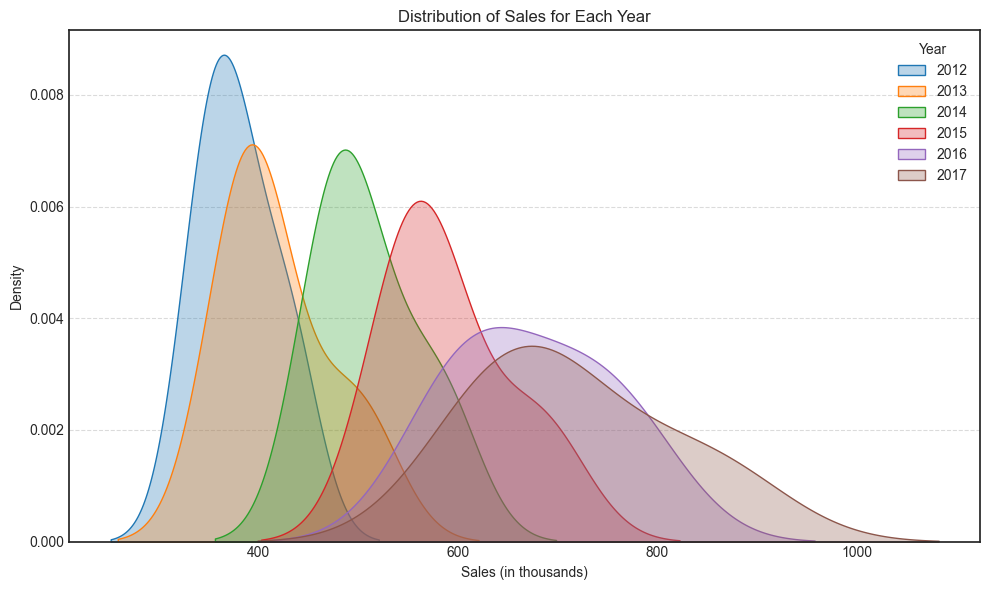


--- Report on Sales Distribution per Year Observations ---
1. **Distribution Peaks Shift:** The distribution peaks clearly shift to the right from 2012 to 2017. This indicates a consistent increase in the typical (most frequent) sales values over the years, signifying a positive overall growth trend in the business.
2. **Change in Width of Distributions:** The width of the distributions (spread) appears to be relatively consistent across years, or perhaps slightly widening for later years. A consistent width suggests that the variability in sales within each year is stable. A slight widening might indicate that as sales grow, the absolute range of sales values also increases, even if the relative variability remains similar.


In [14]:
# Distribution plot of each year
# YOUR CODE HERE
plt.figure(figsize=(10, 6))
for year in years:
    sns.kdeplot(
        sales_data[sales_data["Year"] == year]["Sales"],
        label=str(year),
        fill=True,
        alpha=0.3,
    )
plt.title("Distribution of Sales for Each Year")
plt.xlabel("Sales (in thousands)")
plt.ylabel("Density")
plt.legend(title="Year")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

print("\n--- Report on Sales Distribution per Year Observations ---")
print(
    "1. **Distribution Peaks Shift:** The distribution peaks clearly shift to the right from 2012 to 2017. This indicates a consistent increase in the typical (most frequent) sales values over the years, signifying a positive overall growth trend in the business."
)
print(
    "2. **Change in Width of Distributions:** The width of the distributions (spread) appears to be relatively consistent across years, or perhaps slightly widening for later years. A consistent width suggests that the variability in sales within each year is stable. A slight widening might indicate that as sales grow, the absolute range of sales values also increases, even if the relative variability remains similar."
)


#### Visualize the quarterly sales for each year using a stacked bar plot (1 point)

<Figure size 1200x700 with 0 Axes>

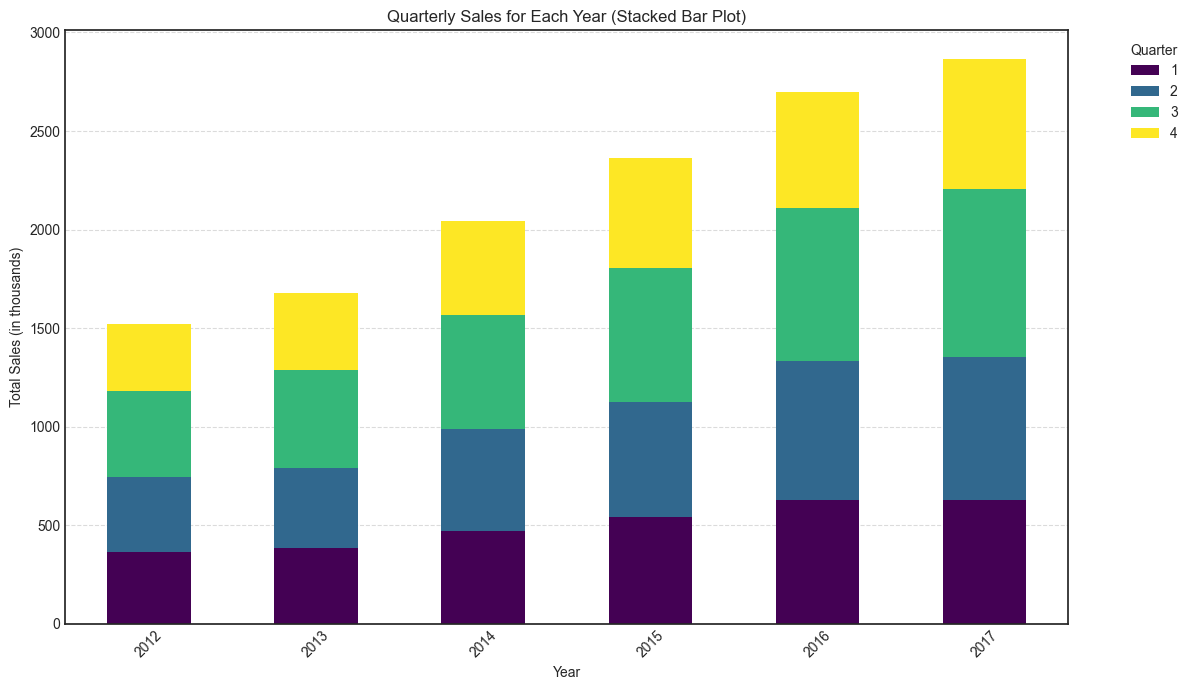

In [15]:
# Plot stacked bar plot
# YOUR CODE HERE
pivot_sales = sales_data.pivot_table(index="Year", columns="Quarter", values="Sales")

plt.figure(figsize=(12, 7))
pivot_sales.plot(kind="bar", stacked=True, colormap="viridis", figsize=(12, 7))
plt.title("Quarterly Sales for Each Year (Stacked Bar Plot)")
plt.xlabel("Year")
plt.ylabel("Total Sales (in thousands)")
plt.xticks(rotation=45)
plt.legend(title="Quarter", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


#### Check if the time series data is stationary (1 point)

Hint:

For the series to be stationary, it must have:
 - constant mean
 - constant variance
 - constant covariance (uncorrelated)

Visualize if the mean is constant

Hint: [Rolling mean](https://pandas.pydata.org/docs/reference/api/pandas.core.window.rolling.Rolling.mean.html)

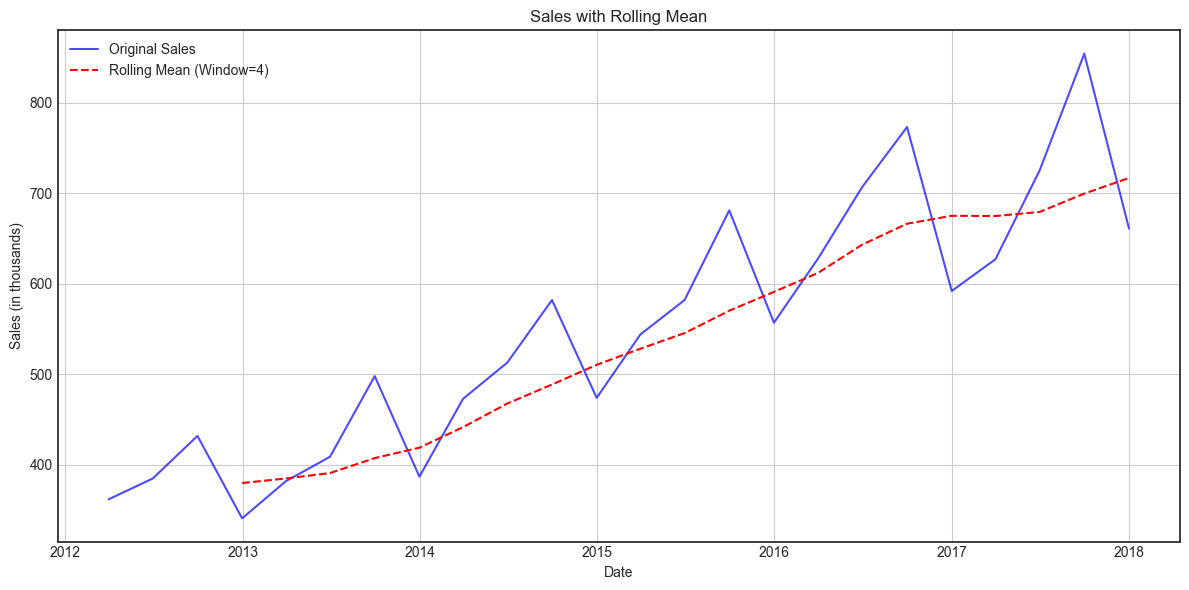

In [ ]:
# Visualize Rolling mean
# YOUR CODE HERE
plt.figure(figsize=(12, 6))
plt.plot(
    sales_data.index,
    sales_data["Sales"],
    label="Original Sales",
    color="blue",
    alpha=0.7,
)
plt.plot(
    sales_data.index,
    sales_data["Sales"].rolling(window=4).mean(),
    label="Rolling Mean (Window=4)",
    color="red",
    linestyle="--",
)
plt.title("Sales with Rolling Mean")
plt.xlabel("Date")
plt.ylabel("Sales (in thousands)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Visualize if the variance is constant

Hint: [Rolling standard deviation](https://pandas.pydata.org/docs/reference/api/pandas.core.window.rolling.Rolling.std.html)

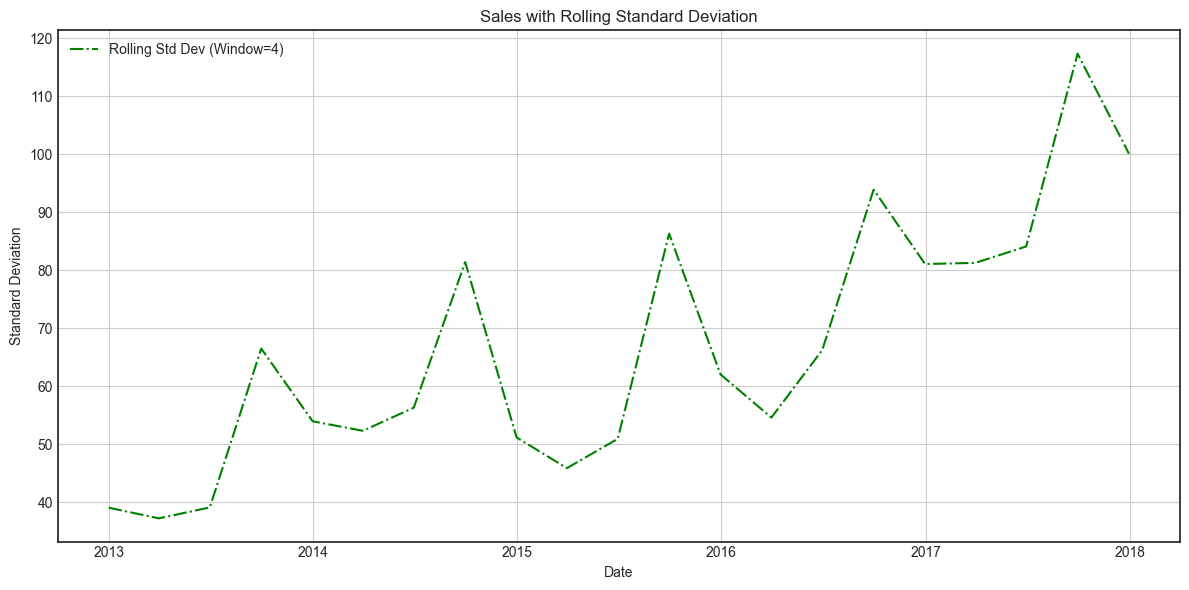


--- Report on Stationarity ---
Based on the observations from the rolling mean and rolling standard deviation plots:
- **Rolling Mean:** The rolling mean shows a clear upward trend, indicating that the mean of the series is not constant over time. This suggests the presence of a trend component.
- **Rolling Standard Deviation:** The rolling standard deviation appears to be relatively stable, indicating that the variance might be constant. However, the presence of a strong trend in the mean is a primary indicator of non-stationarity.
Therefore, the series is **not stationary** due to the clear presence of a trend.


In [18]:
# Rolling standard deviation
# YOUR CODE HERE
plt.figure(figsize=(12, 6))
plt.plot(
    sales_data.index,
    sales_data["Sales"].rolling(window=4).std(),
    label="Rolling Std Dev (Window=4)",
    color="green",
    linestyle="-.",
)
plt.title("Sales with Rolling Standard Deviation")
plt.xlabel("Date")
plt.ylabel("Standard Deviation")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


print("\n--- Report on Stationarity ---")
print(
    "Based on the observations from the rolling mean and rolling standard deviation plots:"
)
print(
    "- **Rolling Mean:** The rolling mean shows a clear upward trend, indicating that the mean of the series is not constant over time. This suggests the presence of a trend component."
)
print(
    "- **Rolling Standard Deviation:** The rolling standard deviation appears to be relatively stable, indicating that the variance might be constant. However, the presence of a strong trend in the mean is a primary indicator of non-stationarity."
)
print(
    "Therefore, the series is **not stationary** due to the clear presence of a trend."
)


Based on the observations report whether the series is stationary or not.

#### Visualize the patterns in time series - trend, seasonality, residuals (1 point)

Hint: See Module 5 - AST2 EDA > Patterns in a time series

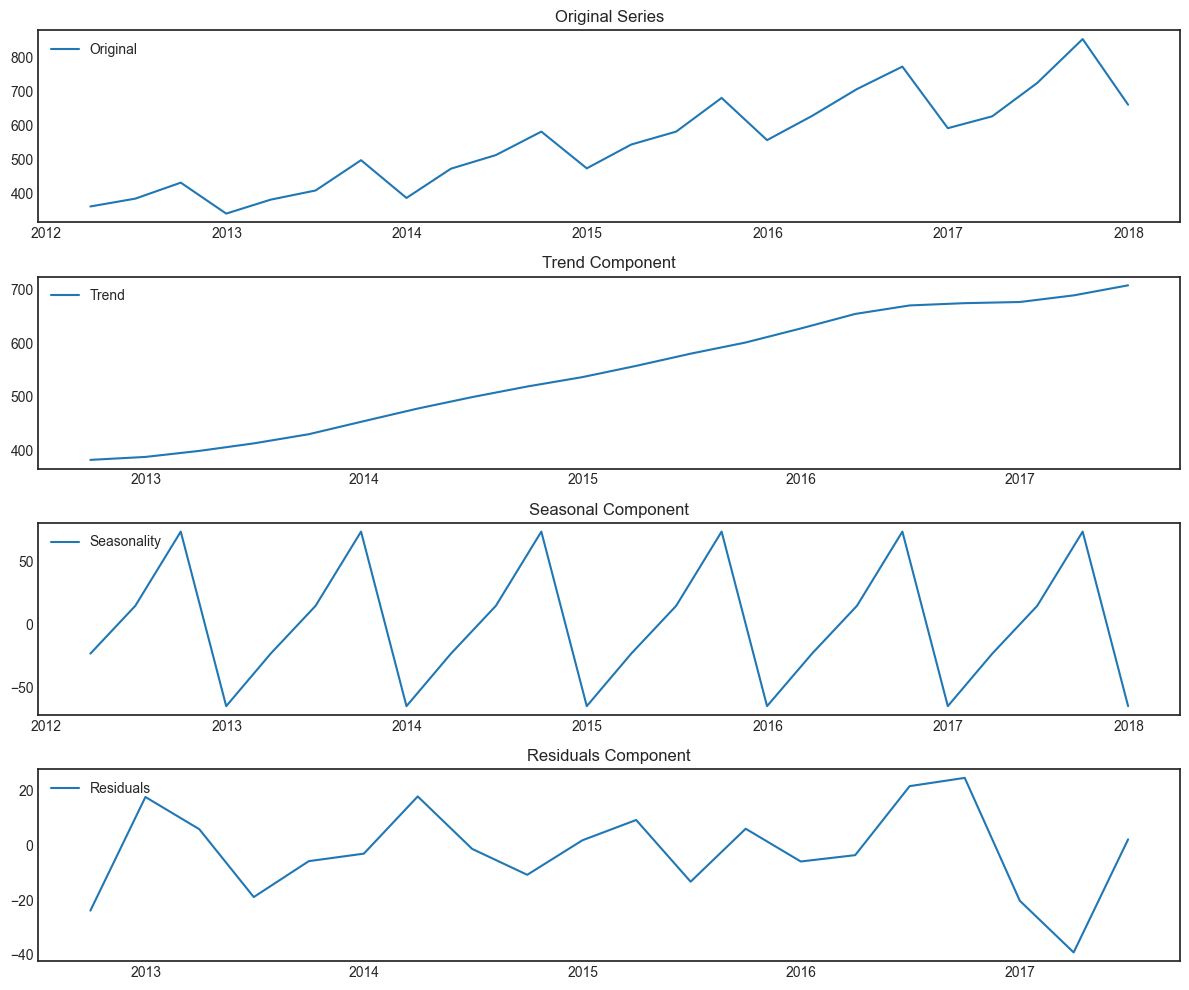


--- Report on Observable Patterns ---
Based on the seasonal decomposition plots:
- **Trend:** There is a clear **upward trend** in the sales data, indicating consistent growth over the years. The trend component captures the long-term direction of the series.
- **Seasonality:** A strong **seasonal pattern** is evident. Sales consistently peak in certain quarters (likely Q4) and dip in others (likely Q1) each year. The seasonal component shows a repeating pattern within each year.
- **Cyclic Behavior:** Given the relatively short time series (6 years of quarterly data), it's difficult to definitively identify long-term business cycles distinct from the overall trend and seasonality. However, the upward trend might be part of a larger, longer-term cycle.
- **Residuals:** The residuals appear to be relatively random, with no obvious patterns or trends, suggesting that the additive model effectively captured the trend and seasonality. The variance of the residuals seems fairly constant, w

In [19]:
# Applying seasonal decompose
# YOUR CODE HERE
# model='additive' is often suitable when the magnitude of seasonal fluctuations is constant over time.
# If fluctuations increase with the level of the series, 'multiplicative' might be better.
decomposition = seasonal_decompose(
    sales_data["Sales"], model="additive", period=4
)  # Period is 4 for quarterly data

# Plotting trend, seasonality
# YOUR CODE HERE
plt.figure(figsize=(12, 10))

plt.subplot(411)
plt.plot(sales_data.index, sales_data["Sales"], label="Original")
plt.legend(loc="upper left")
plt.title("Original Series")

plt.subplot(412)
plt.plot(sales_data.index, decomposition.trend, label="Trend")
plt.legend(loc="upper left")
plt.title("Trend Component")

plt.subplot(413)
plt.plot(sales_data.index, decomposition.seasonal, label="Seasonality")
plt.legend(loc="upper left")
plt.title("Seasonal Component")

plt.subplot(414)
plt.plot(sales_data.index, decomposition.resid, label="Residuals")
plt.legend(loc="upper left")
plt.title("Residuals Component")

plt.tight_layout()
plt.show()

print("\n--- Report on Observable Patterns ---")
print("Based on the seasonal decomposition plots:")
print(
    "- **Trend:** There is a clear **upward trend** in the sales data, indicating consistent growth over the years. The trend component captures the long-term direction of the series."
)
print(
    "- **Seasonality:** A strong **seasonal pattern** is evident. Sales consistently peak in certain quarters (likely Q4) and dip in others (likely Q1) each year. The seasonal component shows a repeating pattern within each year."
)
print(
    "- **Cyclic Behavior:** Given the relatively short time series (6 years of quarterly data), it's difficult to definitively identify long-term business cycles distinct from the overall trend and seasonality. However, the upward trend might be part of a larger, longer-term cycle."
)
print(
    "- **Residuals:** The residuals appear to be relatively random, with no obvious patterns or trends, suggesting that the additive model effectively captured the trend and seasonality. The variance of the residuals seems fairly constant, which supports the choice of an additive model."
)


Report if there are any observable patterns in terms of trend, seasonality , or cyclic behavior.

### **Detrending**

####  Detrend the time series (0.5 point)

Detrending a time series is to remove the trend component from a time series.

Hint:
- Subtract the line of best fit `scipy.signal.detrend()`

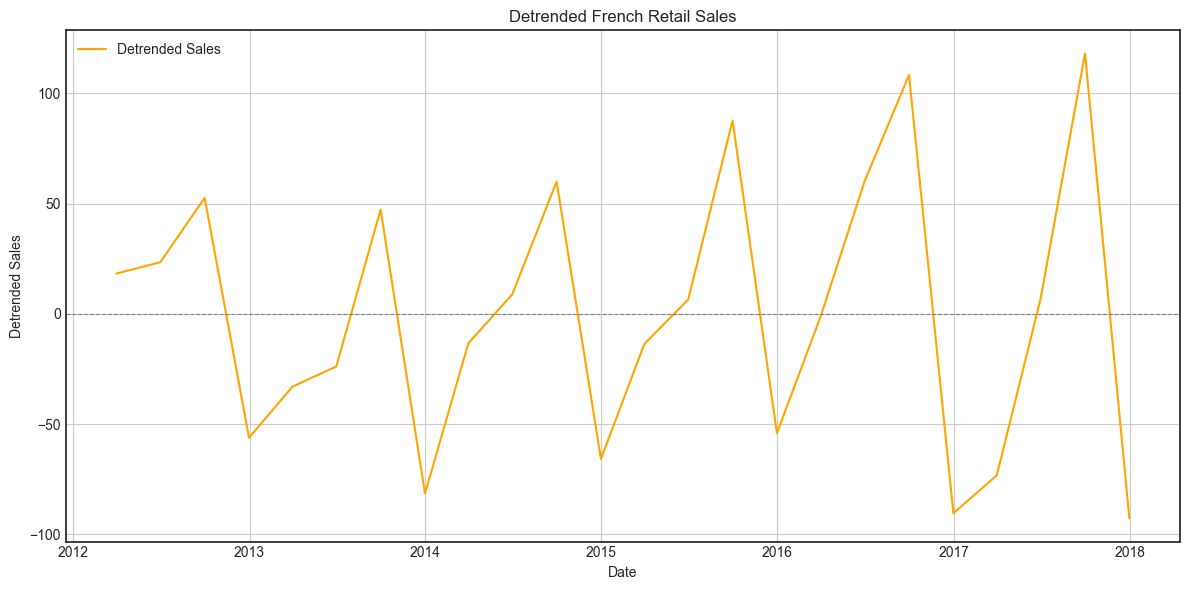


First 5 values of Detrended Sales:
Date
2012-03-31    18.306667
2012-06-30    23.479275
2012-09-30    52.651884
2012-12-31   -56.175507
2013-03-31   -33.002899
Name: Detrended Sales, dtype: float64


In [20]:
# YOUR CODE HERE

# Detrending a time series is to remove the trend component from a time series.
# Subtract the line of best fit `scipy.signal.detrend()`
detrended_sales = scipy.signal.detrend(sales_data["Sales"])

# Create a new DataFrame or Series for the detrended data, maintaining the index
detrended_sales_series = pd.Series(
    detrended_sales, index=sales_data.index, name="Detrended Sales"
)

plt.figure(figsize=(12, 6))
plt.plot(
    detrended_sales_series.index,
    detrended_sales_series,
    color="orange",
    label="Detrended Sales",
)
plt.title("Detrended French Retail Sales")
plt.xlabel("Date")
plt.ylabel("Detrended Sales")
plt.grid(True)
plt.axhline(
    0, color="gray", linestyle="--", linewidth=0.8
)  # Add a zero line for reference
plt.legend()
plt.tight_layout()
plt.show()

print("\nFirst 5 values of Detrended Sales:")
print(detrended_sales_series.head())


### **Lag Plots** (Optional)

#### Visualize the Lag plots

A Lag plot is a scatter plot of a time series against a lag of itself. It is normally used to check for autocorrelation. If there is any pattern existing in the series, the series is autocorrelated. If there is no such pattern, the series is likely to be random white noise.

For reference, see Module 5 - AST2 > Lag Plots

Hint: `pandas.plotting.lag_plot()`

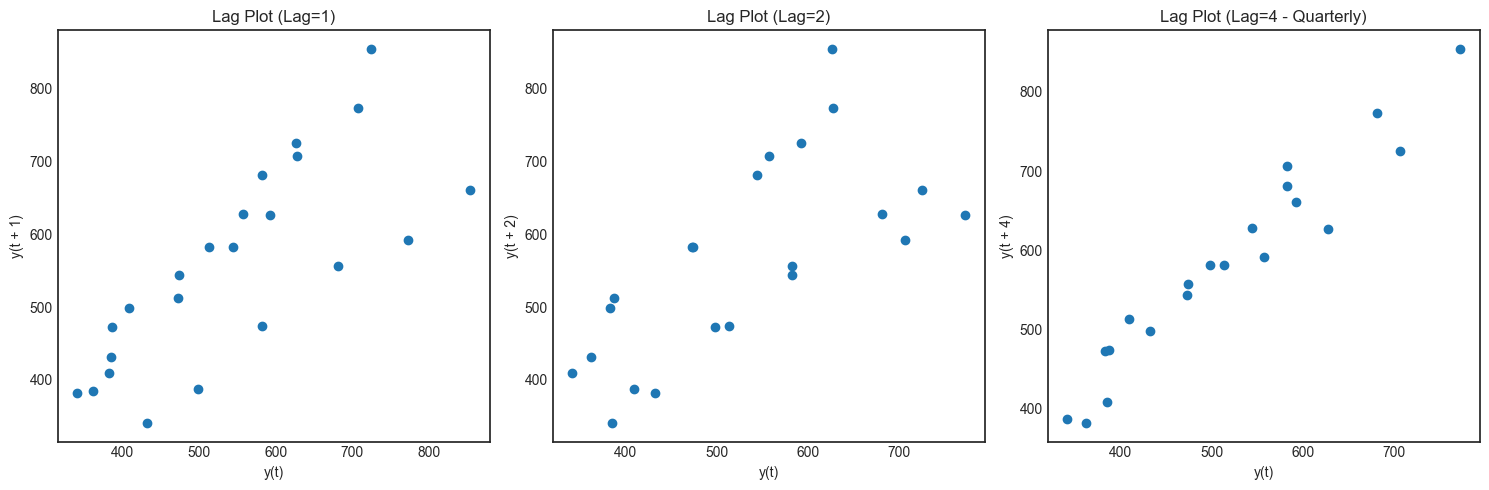


--- Report on Lag Plots ---
- **Lag 1 Plot:** The lag 1 plot shows a strong positive linear relationship, indicating significant positive autocorrelation at lag 1. This means that current sales values are highly correlated with the sales values from the previous quarter.
- **Lag 2 Plot:** The lag 2 plot also shows a positive correlation, though perhaps slightly weaker than lag 1, suggesting that sales two quarters ago still influence current sales.
- **Lag 4 Plot (Quarterly):** The lag 4 plot shows a very strong positive linear relationship, indicating strong positive autocorrelation at lag 4. This confirms the presence of strong seasonality, where sales from the same quarter in the previous year are highly correlated with current sales.
Overall, the lag plots clearly show patterns, confirming that the series is autocorrelated and not random white noise. This is consistent with our earlier observations of trend and seasonality.


In [21]:
# Visualize lag plots
# YOUR CODE HERE
# A Lag plot is a scatter plot of a time series against a lag of itself.
# It is normally used to check for autocorrelation.
# If there is any pattern existing in the series, the series is autocorrelated.
# If there is no such pattern, the series is likely to be random white noise.

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
lag_plot(sales_data["Sales"], lag=1)
plt.title("Lag Plot (Lag=1)")

plt.subplot(1, 3, 2)
lag_plot(sales_data["Sales"], lag=2)
plt.title("Lag Plot (Lag=2)")

plt.subplot(1, 3, 3)
lag_plot(sales_data["Sales"], lag=4)  # For quarterly seasonality
plt.title("Lag Plot (Lag=4 - Quarterly)")

plt.tight_layout()
plt.show()

print("\n--- Report on Lag Plots ---")
print(
    "- **Lag 1 Plot:** The lag 1 plot shows a strong positive linear relationship, indicating significant positive autocorrelation at lag 1. This means that current sales values are highly correlated with the sales values from the previous quarter."
)
print(
    "- **Lag 2 Plot:** The lag 2 plot also shows a positive correlation, though perhaps slightly weaker than lag 1, suggesting that sales two quarters ago still influence current sales."
)
print(
    "- **Lag 4 Plot (Quarterly):** The lag 4 plot shows a very strong positive linear relationship, indicating strong positive autocorrelation at lag 4. This confirms the presence of strong seasonality, where sales from the same quarter in the previous year are highly correlated with current sales."
)
print(
    "Overall, the lag plots clearly show patterns, confirming that the series is autocorrelated and not random white noise. This is consistent with our earlier observations of trend and seasonality."
)


### Report Analysis

- Give the summary about this time series

In [22]:
# Give the summary about this time series
print("\n--- Summary of French Retail Sales Time Series Analysis ---")
print(
    "This mini-project performed an Exploratory Data Analysis (EDA) on quarterly French retail sales data from 2012 to 2017."
)
print("\n**Key Findings:**")
print(
    "1.  **Overall Growth Trend:** The time series exhibits a clear upward trend, indicating consistent growth in retail sales over the observed period. This was evident from the initial time series plot, the shifting peaks in annual sales distributions, and the positive year-on-year percentage growth."
)
print(
    "2.  **Strong Seasonality:** There is a pronounced seasonal pattern, with sales consistently peaking in the fourth quarter (Q4) and typically being lowest in the first quarter (Q1) of each year. This strong seasonality is likely driven by holiday shopping seasons. This was confirmed by quarterly sales subplots, the `quarter_plot`, and strong autocorrelation at lag 4 in the lag plots."
)
print(
    "3.  **Non-Stationarity:** The series is non-stationary primarily due to the presence of a significant trend in the mean. The rolling mean plot clearly showed an increasing average over time, while the rolling standard deviation remained relatively stable."
)
print(
    "4.  **Distribution:** The distribution of sales values is somewhat right-skewed, suggesting that while most quarterly sales fall within a common range, there are fewer instances of exceptionally high sales."
)
print(
    "5.  **Autocorrelation:** Lag plots revealed strong positive autocorrelation, particularly at lags 1 and 4, further confirming the presence of trend and seasonality within the data."
)
print(
    "6.  **Detrending:** The series was successfully detrended using `scipy.signal.detrend()`, resulting in a series that fluctuates around a zero mean, highlighting the underlying seasonal patterns more clearly."
)

print("\n**Implications for Forecasting:**")
print(
    "Given the strong trend and seasonality, a forecasting model for this time series would need to explicitly account for both components. Techniques like ARIMA (specifically SARIMA for seasonality), Exponential Smoothing (e.g., Holt-Winters), or Prophet would be suitable choices to capture these patterns effectively for future sales predictions."
)



--- Summary of French Retail Sales Time Series Analysis ---
This mini-project performed an Exploratory Data Analysis (EDA) on quarterly French retail sales data from 2012 to 2017.

**Key Findings:**
1.  **Overall Growth Trend:** The time series exhibits a clear upward trend, indicating consistent growth in retail sales over the observed period. This was evident from the initial time series plot, the shifting peaks in annual sales distributions, and the positive year-on-year percentage growth.
2.  **Strong Seasonality:** There is a pronounced seasonal pattern, with sales consistently peaking in the fourth quarter (Q4) and typically being lowest in the first quarter (Q1) of each year. This strong seasonality is likely driven by holiday shopping seasons. This was confirmed by quarterly sales subplots, the `quarter_plot`, and strong autocorrelation at lag 4 in the lag plots.
3.  **Non-Stationarity:** The series is non-stationary primarily due to the presence of a significant trend in the 